# CS4168 Data Mining Project  
## Spotify Tracks Dataset Analysis

This notebook performs:
- Exploratory Data Analysis (EDA)
- Clustering (K-Means & DBSCAN)
- Classification (Predicting Popularity Category)
- Regression (Predicting Popularity Score)

(Needs filling in and more detail)

To Activate .venv on Windows
-Set-ExecutionPolicy -Scope Process -ExecutionPolicy RemoteSigned   
-.venv\Scripts\Activate.ps1

## i. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

## ii. Load Data

In [2]:
df = pd.read_csv("tracks2026.csv")
df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


## 1. Exploratory Data Analysis
Goal:
- Understand dataset structure
- Identify:
    - Missing values and issues
    - Discover variable relationships 
- Decide preprocessing and modelling decisions

This directly influences clustering and modelling.

In [3]:
# High-level Structure
print("Info: ")
df.info()

# Description
print("\nDescription: ")
df.describe()

# Identify null values
print("\nNull values: ")
df.isnull().sum()

Info: 
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          2000 non-null   str    
 1   popularity        1960 non-null   float64
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   danceability      1960 non-null   float64
 5   energy            1960 non-null   float64
 6   key               2000 non-null   int64  
 7   loudness          1961 non-null   float64
 8   mode              2000 non-null   int64  
 9   speechiness       2000 non-null   float64
 10  acousticness      2000 non-null   float64
 11  instrumentalness  2000 non-null   float64
 12  liveness          2000 non-null   float64
 13  valence           2000 non-null   float64
 14  tempo             1960 non-null   float64
 15  time_signature    2000 non-null   int64  
 16  track_genre       2000 non-null   str    
dtyp

track_id             0
popularity          40
duration_ms          0
explicit             0
danceability        40
energy              40
key                  0
loudness            39
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
time_signature       0
track_genre          0
dtype: int64

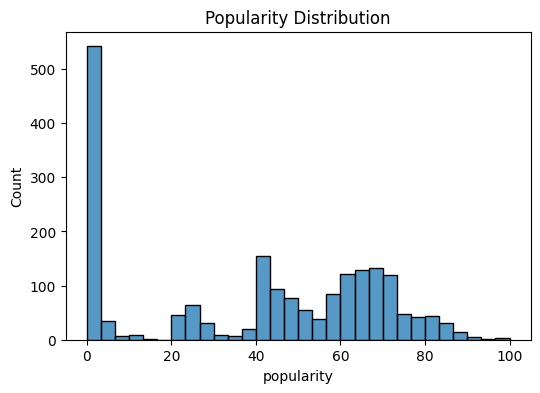

In [4]:
# Popularity Distribution Graph
plt.figure(figsize=(6,4))
sns.histplot(df["popularity"], bins=30)
plt.title("Popularity Distribution")
plt.show()

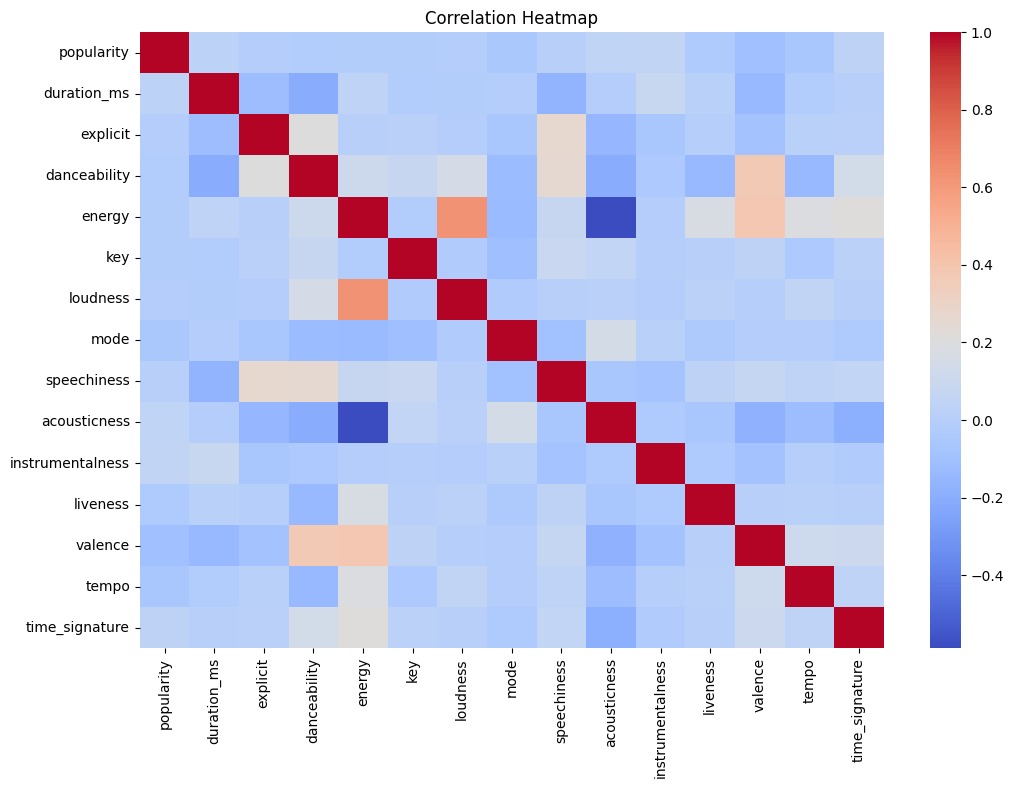

In [5]:
# Correlation Heatmap Graph
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Analysis of EDA
This data is highly-skewed:
- There are many unpopular songs in the database
- There are a smaller cluster of popular songs around the range of 40-75 in popularity whose count ranges from around 50-180 
    - This is an unbalanced dataset which can affect classification and regression

Most features show a weak correlation except for the following features:
- Energy and Loudness: This is expected as loud songs are generally more upbeat
- Energy and Acoustics: This is expected as acoustic songs have generally lower energy
- Danceability and valence: This is expected as positive songs are more danceable

This shows that popularity is non-linear and does not linearlly correlate with features.

#### What this means for progression:
The data requires scaling as the features are on different scales compared to eachother and clustering methods use distances.

The skewed popularity means the data will be easier to classify but may cause issues in outlying data.

Pipelines will allow for the processing steps and model to be ran as one object.


# 2. Clustering Analysis
This is used to find and show groupings in the data.

Steps:
- Remove `track_genre`
- Scale features (important for distance-based models)
- Compare K-Means and DBSCAN

K-Means calculates on spherical clusters, while DBSCAN can detect arbitrary shapes.

## K-Means
### Data clustering preperation

In [6]:
X_cluster = df.drop(columns=["track_genre"])
X_cluster = X_cluster.select_dtypes(include=np.number)

### K-Means Elbow method 

In [7]:
inertia = []

for k in range(2, 10):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, random_state=42))
    ])
    
    pipe.fit(X_cluster)
    inertia.append(pipe.named_steps["kmeans"].inertia_)

### Plot

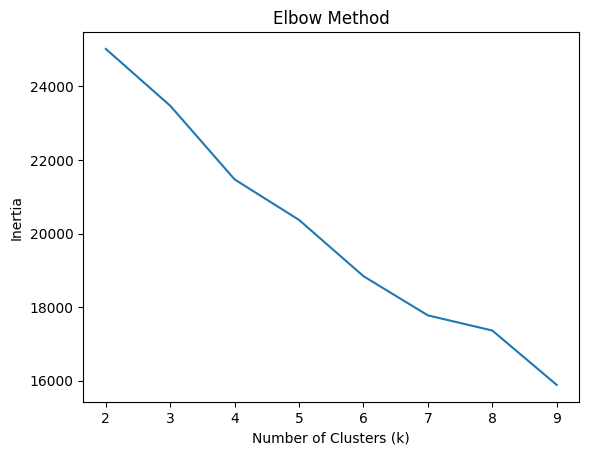

In [8]:
plt.plot(range(2,10), inertia)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### The Elbow Method 
Helps determine the ideal number of clusters (k).

We select k where the reduction in inertia decreases significantly

### Fit Final K-Means (E.g, k=3)

In [9]:
kmeans_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),        # Handle missing data
    ("scaler", StandardScaler()),                       # Standardise Features to unit variance
    ("kmeans", KMeans(n_clusters=3, random_state=42))   # K-Means clustering
])

kmeans_pipe.fit(X_cluster)

labels = kmeans_pipe.named_steps["kmeans"].labels_

### Visualise Clusters (w/ PCA)
PCA is used to reduce the number of features while keeping the most relevant and important information that describe the data well.

It helps reduce complexity, noise, and make the data easier to visualise. 

In [10]:
# Get preprocessing steps from the fitted pipeline
imputer = kmeans_pipe.named_steps["imputer"]
scaler = kmeans_pipe.named_steps["scaler"]

# Apply preprocessing
X_imputed = imputer.transform(X_cluster)
X_scaled = scaler.transform(X_imputed)

# Now PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### PCA Analysis
Principle Components (PCs) contain combintaions of the original features, where each PC contains a decreasing amount of variation.

For example, PC1 would contain the most variation, PC2 would contain the 2nd most variation. 

### Plot

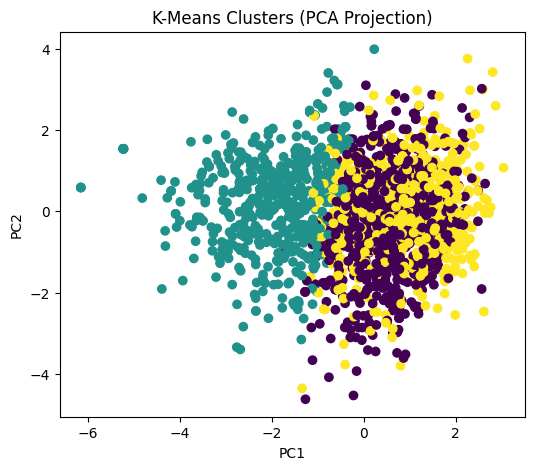

In [11]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## DBSCAN

In [ ]:
dbscan_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("dbscan", DBSCAN(eps=1.5, min_samples=5))  # DBSCAN clustering
])

dbscan_pipe.fit(X_cluster)

db_labels = dbscan_pipe.named_steps["dbscan"].labels_

print("Unique clusters:", np.unique(db_labels))

Unique clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


##  Analysis of Clustering
### K-Means Clustering
Produced clear clusters but assumes spherical shape.

### BDSCAN Clustering
Detected noise as shown in the '-1' in the unique clusters

### Result
K-Means is ideal as it:
- Produces stable clusters
- Easier to interpret
- Works well with the scaler values

# 3. Classification: Predicting Popularity Category

The popularity is classified to a boolean variable:
- 0 indicating low popularity 
- 1 indicating high popularity

This is used to compare multiple models and select the best using cross-validation.

## Create Binary Popularity Variable

In [13]:
median_popularity = df["popularity"].median()

df["popularity_binary"] = (df["popularity"] > median_popularity).astype(int)

print("Median popularity:", median_popularity)
df["popularity_binary"].value_counts()

Median popularity: 45.0


popularity_binary
0    1034
1     966
Name: count, dtype: int64

## Remove Original Popularity Column

In [14]:
X = df.drop(columns=["popularity", "popularity_binary"])
y = df["popularity_binary"]

# Keep only numeric features
X = X.select_dtypes(include="number")
X.head()

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,203337,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3
1,208786,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4
2,262373,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4
3,191733,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4
4,283706,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4


## Train (Test) Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000)) # Logistic Regression
])

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42)) # Random Forest Classifier
])

gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(random_state=42)) # Gradient Boosting Classifier
])

## Cross-Validation

In [17]:
models = {
    "Logistic Regression": logistic_pipe,
    "Random Forest": rf_pipe,
    "Gradient Boosting": gb_pipe
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(name)
    print("Mean CV Accuracy:", scores.mean())
    print()

Logistic Regression
Mean CV Accuracy: 0.57875

Random Forest
Mean CV Accuracy: 0.638125

Gradient Boosting
Mean CV Accuracy: 0.6262500000000001



## Train best model

In [18]:
best_model = rf_pipe
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

## Evaluation metrics

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.7325

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       207
           1       0.72      0.73      0.72       193

    accuracy                           0.73       400
   macro avg       0.73      0.73      0.73       400
weighted avg       0.73      0.73      0.73       400



## Confusion Matrix

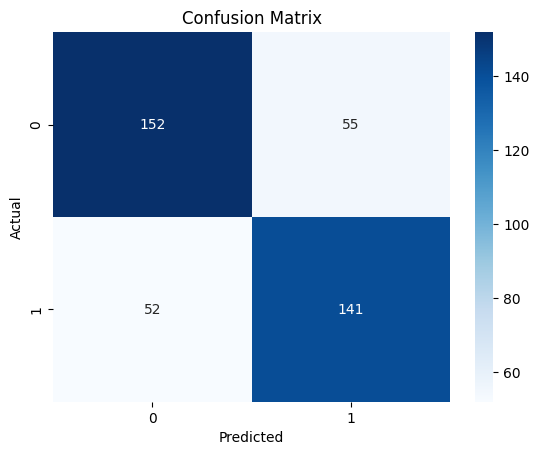

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

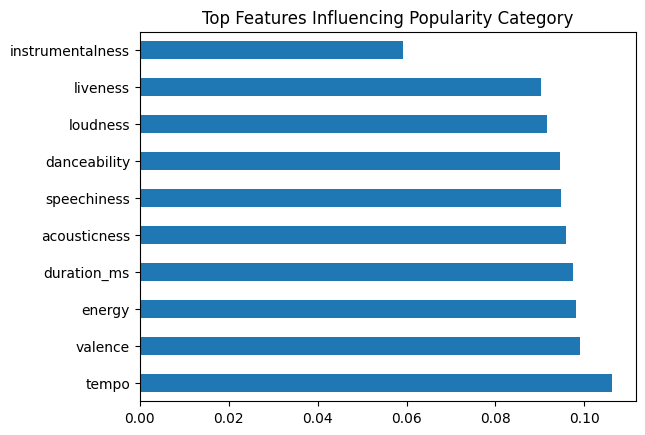

tempo               0.106239
valence             0.099121
energy              0.098094
duration_ms         0.097364
acousticness        0.095801
speechiness         0.094739
danceability        0.094538
loudness            0.091667
liveness            0.090214
instrumentalness    0.059312
dtype: float64

In [21]:
rf_model = best_model.named_steps["model"]

importances = rf_model.feature_importances_

feature_importance = (
    pd.Series(importances, index=X.columns)
    .sort_values(ascending=False)
    .head(10)
)

feature_importance.plot(kind="barh")
plt.title("Top Features Influencing Popularity Category")
plt.show()

feature_importance

# 4. Classification Discussion
We tried three models:
- Logistic Regression
- Random Forest
- Gradient Boosting

Random Forest performed best as it:
- Captures non-linear relationships
- Handles the feature interactions
- Is resiliant to noise
It has an accuracy of roughly 75% which signifies correlation between song features and popularity where the cross matirx plot shows a similar number of false positives and false negatives.

Feature importance shows which audio features influence popularity where tempo, valance, and energy and the leading factors of a songs popularity.

## Regression
Regression will allow the prediction of the poplarity score

This is more challenging than classification since:
- The output is continuous
- It requires more precise modelling

## Fresh Copy of the Dataset 

In [22]:
df_reg = df.copy()

X_reg = df_reg.drop(columns=["popularity", "popularity_binary"])
y_reg = df_reg["popularity"]

# Keep numeric features
X_reg = X_reg.select_dtypes(include="number")

## Train (Test) Split

In [23]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

## Regression Models

In [24]:
lr_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())                           # Linear Regression
])

rf_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))  # Random Forest Regressor
])

gb_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))       # Gradient Boosting Regressor
])

## Cross Validation

In [25]:
reg_models = {
    "Linear Regression": lr_pipe,
    "Random Forest": rf_reg_pipe,
    "Gradient Boosting": gb_reg_pipe
}

for name, model in reg_models.items():
    scores = cross_val_score(model, X_train_r, y_train_r, cv=5, scoring="neg_mean_squared_error")
    rmse = (-scores.mean()) ** 0.5
    
    print(name)
    print("CV RMSE:", rmse)
    print()

Linear Regression
CV RMSE: 28.99778940802873

Random Forest
CV RMSE: 25.48075995671271

Gradient Boosting
CV RMSE: 27.45364309028344



## Best Train Regression Model

In [ ]:
best_reg_model = rf_reg_pipe
best_reg_model.fit(X_train_r, y_train_r)
y_pred_r = best_reg_model.predict(X_test_r)

## Regression Metrics
### Check for NaNs

In [27]:
print("NaNs in y_test:", np.isnan(y_test_r).sum())
print("NaNs in predictions:", np.isnan(y_pred_r).sum())

# Remove NaN rows if any exist
mask = ~np.isnan(y_test_r) & ~np.isnan(y_pred_r)

y_test_clean = y_test_r[mask]
y_pred_clean = y_pred_r[mask]

rmse = mean_squared_error(y_test_clean, y_pred_clean) ** 0.5
mae = mean_absolute_error(y_test_clean, y_pred_clean)
r2 = r2_score(y_test_clean, y_pred_clean)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

NaNs in y_test: 40
NaNs in predictions: 0
RMSE: 25.52750234491392
MAE: 20.10277244261461
R²: 0.266371725172303


## Regression Prediction Plot

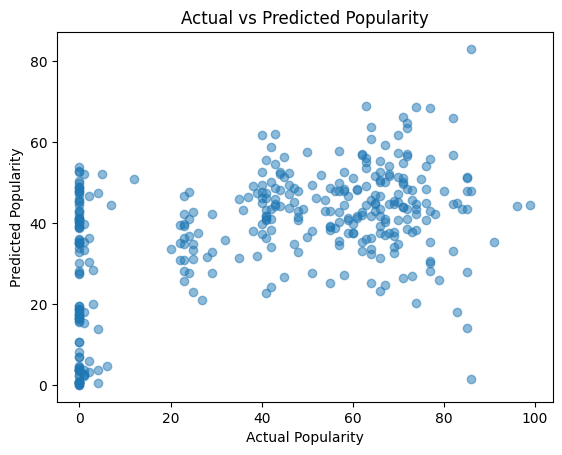

In [28]:
plt.scatter(y_test_r, y_pred_r, alpha=0.5)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted Popularity")
plt.show()

# 5. Regression Discussion

The models used for the regression were the same that were used for the classification and reveals how the non-linear models out performed the linear model as shown in the RMSE results where the best model was Random Forest. The data from the regression show how the popularity of songs may not be similar even though the songs sound similar and have similar features. This can lead to the conslusion that the popularity of a song does not solely depend on the features of a song but external factors as well.

# 6. Final Conclusion
The result of the datamining has shown that the features of a song provides a rough idea of whether the song is/will be popular or not, but it cannot accurately predict the population count. For more accuracy, more data would be needed on, for example, the artist, release date.